In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib.patches import Rectangle
from pathlib import Path
from typing import List, Union
from scipy.linalg import solve_triangular, qr
import json
import re
import os
import uproot
import importlib.util
plt.style.use(hep.style.CMS)

In [ ]:
label_map_nj = {
     'nj_bin0': 'r_NJ_0p0_1p0',
 'nj_bin1': 'r_NJ_1p0_2p0',
 'nj_bin2': 'r_NJ_2p0_3p0',
 'nj_bin3': 'r_NJ_3p0_4p0',
 'nj_bin4': 'r_NJ_4p0_100p0',
}


pois = {
    "PTH": ["r_PTH_0p0_5p0","r_PTH_5p0_10p0","r_PTH_10p0_15p0","r_PTH_15p0_20p0","r_PTH_20p0_25p0","r_PTH_25p0_30p0","r_PTH_30p0_35p0","r_PTH_35p0_45p0","r_PTH_45p0_60p0","r_PTH_60p0_80p0","r_PTH_80p0_100p0","r_PTH_100p0_120p0","r_PTH_120p0_140p0","r_PTH_140p0_170p0","r_PTH_170p0_200p0","r_PTH_200p0_250p0","r_PTH_250p0_350p0","r_PTH_350p0_450p0","r_PTH_450p0_10000p0"],
    "NJ": ["r_NJ_0p0_1p0", "r_NJ_1p0_2p0", "r_NJ_2p0_3p0", "r_NJ_3p0_4p0", "r_NJ_4p0_100p0"],
    "PTJ0": ["r_PTJ0_m10000p0_30p0", "r_PTJ0_30p0_40p0", "r_PTJ0_40p0_55p0", "r_PTJ0_55p0_75p0", "r_PTJ0_75p0_95p0", "r_PTJ0_95p0_120p0", "r_PTJ0_120p0_150p0", "r_PTJ0_150p0_200p0", "r_PTJ0_200p0_10000p0"],
    "YH": ["r_YH_0p0_0p15", "r_YH_0p15_0p3", "r_YH_0p3_0p45", "r_YH_0p45_0p6", "r_YH_0p6_0p75", "r_YH_0p75_0p9", "r_YH_0p9_1p2", "r_YH_1p2_1p6", "r_YH_1p6_2p0", "r_YH_2p0_2p5"]
}

In [ ]:
palette = sns.diverging_palette(240, 10, n=20, as_cmap=True)


# Plot correlation matrix at gen-level
def plot_corr(_corr_gen, title="Correlation Matrix (Generator Level)", save_path=None, label_map=None):
    corr_gen_mask = np.triu(np.ones_like(_corr_gen, dtype=bool), k=1)
    fig_corr_gen, ax_corr_gen = plt.subplots(figsize=(28, 18), constrained_layout=True)
    sns.heatmap(
        _corr_gen,
        ax=ax_corr_gen,
        cmap=palette,
        mask=corr_gen_mask,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        center=0,
        square=True,
        annot_kws={"size": 10, "weight": "bold"},
        cbar_kws={"label": "Correlation"},
    )
    ax_corr_gen.set_title(title)
    ax_corr_gen.set_xlabel("Bins")
    ax_corr_gen.set_ylabel("Bins")
    
    # ---- LABEL TRANSLATION LOGIC ----
    if label_map is not None:
        # assume index == columns order
        original_labels = list(_corr_gen.index)

        translated_labels = [
            label_map.get(lbl, lbl) for lbl in original_labels
        ]

        ax_corr_gen.set_xticklabels(translated_labels, rotation=90, fontsize=12)
        ax_corr_gen.set_yticklabels(translated_labels, rotation=0, fontsize=12)
        # IMPORTANT: re-apply tick styling AFTER setting labels
        ax_corr_gen.tick_params(
            axis="x",
            which="both",
            length=0,   # <- removes tick marks
            bottom=False,
            top=False
        )
        ax_corr_gen.tick_params(
            axis="y",
            which="both",
            length=0,   # <- removes tick marks
            left=False,
            right=False
        )

    else:
        ax_corr_gen.tick_params(
            axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0, labelsize=12
        )
        ax_corr_gen.tick_params(
            axis="y", which="both", labelrotation=0, left=False, right=False, length=0, labelsize=12
        )

    ax_corr_gen.minorticks_off()

    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()

# Plot covariance matrix at gen-level
def plot_cov(_corr_gen, title="Covariance Matrix (Generator Level)", save_path=None, label_map=None):
    corr_gen_mask = np.triu(np.ones_like(_corr_gen, dtype=bool), k=1)
    fig_corr_gen, ax_corr_gen = plt.subplots(figsize=(28, 18), constrained_layout=True)
    sns.heatmap(
        _corr_gen,
        ax=ax_corr_gen,
        cmap=palette,
        mask=corr_gen_mask,
        vmin = _corr_gen.to_numpy().min(),
        vmax = _corr_gen.to_numpy().max(),
        annot=True,
        fmt=".2f",
        center=0,
        square=True,
        annot_kws={"size": 10, "weight": "bold"},
        cbar_kws={"label": r"Theoretical Covariance [fb$^{2}$]"},
        # cbar_kws={"label": "Theoretical Covariance"},
    )
    ax_corr_gen.set_title(title)
    ax_corr_gen.set_xlabel("Bins")
    ax_corr_gen.set_ylabel("Bins")
    
    # ---- LABEL TRANSLATION LOGIC ----
    if label_map is not None:
        # assume index == columns order
        original_labels = list(_corr_gen.index)

        translated_labels = [
            label_map.get(lbl, lbl) for lbl in original_labels
        ]

        ax_corr_gen.set_xticklabels(translated_labels, rotation=90, fontsize=12)
        ax_corr_gen.set_yticklabels(translated_labels, rotation=0, fontsize=12)
        # IMPORTANT: re-apply tick styling AFTER setting labels
        ax_corr_gen.tick_params(
            axis="x",
            which="both",
            length=0,   # <- removes tick marks
            bottom=False,
            top=False
        )
        ax_corr_gen.tick_params(
            axis="y",
            which="both",
            length=0,   # <- removes tick marks
            left=False,
            right=False
        )

    else:
        ax_corr_gen.tick_params(
            axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0, labelsize=12
        )
        ax_corr_gen.tick_params(
            axis="y", which="both", labelrotation=0, left=False, right=False, length=0, labelsize=12
        )

    ax_corr_gen.minorticks_off()

    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()


def corr_from_cov(cov_mat: pd.DataFrame) -> pd.DataFrame:
    v = np.diag(cov_mat.to_numpy())
    sigma = np.sqrt(np.clip(v, 0.0, None))
    with np.errstate(divide="ignore", invalid="ignore"):
        outer = np.outer(1.0 / sigma, 1.0 / sigma)
        arr = outer * cov_mat.to_numpy()
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(arr, 1.0)
    return pd.DataFrame(arr, index=cov_mat.index, columns=cov_mat.columns)


In [124]:
# For the moment only using NJ. I wanna see first if it is working....

FILE_RE = re.compile(
    r"^fidXS_(?P<obs>NJ)_all_exclusive\.py$"
)

def load_python_module(path: Path):
    spec = importlib.util.spec_from_file_location(path.stem, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load file: {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

var = {
    "scale": {
        "NJ": [],
    }
}

fidXS_folder = Path("fidXS")

for path in fidXS_folder.iterdir():
    match = FILE_RE.match(path.name)
    if not match:
        continue

    obs = match.group("obs")

    module = load_python_module(path)

    if not hasattr(module, "fidXS"):
        print(f"Skipping {path.name}: no fidXS vector")
        continue

    fid_xs_nom = np.array(list(module.fidXS))  # convert once to numpy
    fid_xs_scale_up = np.array(list(module.fidXS_scale_up))
    
    for i, nom_xs in enumerate(fid_xs_nom):
        var["scale"][obs].append(fid_xs_scale_up[i] - fid_xs_nom[i])



# We fully correlate the theory uncertainties (WRONG APPROACH)

# Build the correlation matrix
n_bins = len(var["scale"]["NJ"])
matrix = np.ones((5, 5), dtype=int)

# Use the dictionary values (or keys) as labels
labels = list(label_map_nj.values())

correlation = pd.DataFrame(
    matrix,
    index=labels,
    columns=labels
)

correlation = correlation * 1

# Build the global ordered list of bins
all_bins = []
all_bins.extend(pois["NJ"])

# Replace the nested dicts with column-vector DataFrames
for source in var:

    values = []

    values.extend(var[source]["NJ"])

    var[source] = pd.DataFrame(
        values,
        index=all_bins,
        columns=[source]
    )


# Now compute the covariance per source

v_scale = var["scale"].iloc[:, 0]
Cov_scale_NJ = correlation.mul(v_scale, axis=0).mul(v_scale, axis=1)

# plot_corr(Cov_scale_NJ, title="Covariance (No Tackmann)")
Cov_scale_NJ

,r_NJ_0p0_1p0,r_NJ_1p0_2p0,r_NJ_2p0_3p0,r_NJ_3p0_4p0,r_NJ_4p0_100p0
r_NJ_0p0_1p0,NaN,NaN,NaN,NaN,NaN
r_NJ_1p0_2p0,NaN,NaN,NaN,NaN,NaN
r_NJ_2p0_3p0,NaN,NaN,NaN,NaN,NaN
r_NJ_3p0_4p0,NaN,NaN,NaN,NaN,NaN
r_NJ_4p0_100p0,NaN,NaN,NaN,NaN,NaN


In [125]:
def long_range_st(sigma, sigma_up, sigma_dn):
    sigma = np.array(sigma)
    up = np.array(sigma_up)
    dn = np.array(sigma_dn)

    nbins = len(sigma)

    # --------------------------------------------------
    # 1. absolute uncertainties (envelope)
    # --------------------------------------------------
    Delta = np.maximum(np.abs(up - sigma), np.abs(dn - sigma))

    # relative uncertainties
    delta = Delta / np.clip(sigma, 1e-12, None)

    # --------------------------------------------------
    # 2. covariance construction
    # --------------------------------------------------
    Cov = np.zeros((nbins, nbins))

    # --- normalization-like component (NP total)
    v_norm = Delta
    Cov += np.outer(v_norm, v_norm)

    # --------------------------------------------------
    # 3. migration components (long-range ST)
    # --------------------------------------------------
    for i in range(nbins - 1):
        hi = i + 1

        # migration size (from slide)
        sigma_hi = sigma[hi]
        sigma_lo = sigma[i]

        if sigma_hi <= 0 or sigma_lo <= 0:
            continue

        # relative migration
        d_hi = Delta[hi] / sigma_hi

        # construct migration vector
        v = np.zeros(nbins)

        # + in high bin
        v[hi] = +d_hi * sigma_hi

        # - in low bin (compensation)
        v[i] = -d_hi * sigma_hi * (sigma_hi / sigma_lo)
        
        print(v)

        Cov += np.outer(v, v)

    return Cov

In [126]:
FILE_RE = re.compile(
    r"^fidXS_(?P<obs>NJ)_all_inclusive\.py$"
)

def load_python_module(path: Path):
    spec = importlib.util.spec_from_file_location(path.stem, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load file: {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

var = {
    "scale": {
        "NJ": [],
    }
}

fidXS_folder = Path("fidXS")

for path in fidXS_folder.iterdir():
    match = FILE_RE.match(path.name)
    if not match:
        continue

    obs = match.group("obs")

    module = load_python_module(path)

    if not hasattr(module, "fidXS"):
        print(f"Skipping {path.name}: no fidXS vector")
        continue

    sigma = np.array(list(module.fidXS))  # convert once to numpy
    up = np.array(list(module.fidXS_scale_up))
    dn = np.array(list(module.fidXS_scale_dn))
    

    Delta_up = up - sigma
    Delta_dn = dn - sigma

    # # envelope (standard theory choice)
    # Delta_ge = np.maximum(np.abs(Delta_up), np.abs(Delta_dn))
    
    # sigma_excl = np.zeros_like(sigma)

    # sigma_excl[0] = sigma[0] - sigma[1]
    # sigma_excl[1] = sigma[1] - sigma[2]
    # sigma_excl[2] = sigma[2] - sigma[3]
    # sigma_excl[3] = sigma[3] - sigma[4]
    # sigma_excl[4] = sigma[4]
    
    # modes = []

    # # ≥0 mode
    # v0 = np.array([1,1,1,1,1]) * Delta_ge[0]
    # modes.append(v0)

    # # ≥1 mode
    # v1 = np.array([0,1,1,1,1]) * Delta_ge[1]
    # modes.append(v1)

    # # ≥2 mode
    # v2 = np.array([0,0,1,1,1]) * Delta_ge[2]
    # modes.append(v2)

    # # ≥3 mode
    # v3 = np.array([0,0,0,1,1]) * Delta_ge[3]
    # modes.append(v3)

    # # ≥4 mode
    # v4 = np.array([0,0,0,0,1]) * Delta_ge[4]
    # modes.append(v4)
    
    # Cov = np.zeros((5,5))
    
    # for v in modes:
    #     Cov += np.outer(v, v)
    Cov = long_range_st(sigma, up, dn)
        
    # print(corr_from_cov(pd.DataFrame(Cov)))
    print(Cov)
    
# # 4. covariance
# V = np.vstack([Delta_0, Delta_1, Delta_2, Delta_3, Delta_4])
# Cov_scale_NJ = V @ V.T

# corr_from_cov(pd.DataFrame(Cov_scale_NJ))
# # plot_corr(Cov_scale_NJ, title="Covariance (Tackmann)")

[-1.30439642  2.81488344  0.          0.          0.        ]
[ 0.         -0.53149533  1.38800587  0.          0.        ]
[ 0.          0.         -0.1155434   0.42796212  0.        ]
[ 0.          0.          0.         -0.0507038   0.14739777]
[[ 8.5986916   3.72089189  3.6452643   1.12393979  0.38710487]
 [ 3.72089189 16.12962483  3.1693561   1.20466347  0.41490754]
 [ 3.6452643   3.1693561   3.86647087  0.54456573  0.20458897]
 [ 1.12393979  1.20466347  0.54456573  0.36887402  0.05560703]
 [ 0.38710487  0.41490754  0.20458897  0.05560703  0.0434522 ]]


In [127]:
### Kljinsma method

In [145]:
FILE_RE = re.compile(
    r"^fidXS_(?P<obs>PTH|NJ|PTJ0|YH)_all_(?P<scale>0|1|3|5|7|8)\.py$"
)

def load_python_module(path: Path):
    spec = importlib.util.spec_from_file_location(path.stem, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load file: {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

scale_variations = {
    "0": {
        "PTH": [],
        "NJ": [],
        "PTJ0": [],
        "YH": [],
    },
    "1": {
        "PTH": [],
        "NJ": [],
        "PTJ0": [],
        "YH": [],
    },
    "3": {
        "PTH": [],
        "NJ": [],
        "PTJ0": [],
        "YH": [],
    },
    "5": {
        "PTH": [],
        "NJ": [],
        "PTJ0": [],
        "YH": [],
    },
    "7": {
        "PTH": [],
        "NJ": [],
        "PTJ0": [],
        "YH": [],
    },
    "8": {
        "PTH": [],
        "NJ": [],
        "PTJ0": [],
        "YH": [],
    }
}

fidXS_folder = Path("fidXS")

for path in fidXS_folder.iterdir():
    match = FILE_RE.match(path.name)
    if not match:
        continue

    obs = match.group("obs")
    scale = match.group("scale")

    module = load_python_module(path)

    if not hasattr(module, "fidXS"):
        print(f"Skipping {path.name}: no fidXS vector")
        continue

    sigma = np.array(list(module.fidXS))  # convert once to numpy
    up = np.array(list(module.fidXS_scale_up))
    
    scale_variations[scale][obs] = up - sigma
    
    


In [146]:
scale_variations

{'0': {'PTH': array([-0.14198193, -0.24635376, -0.22926008, -0.14859067, -0.0502524 ,
          0.03994799,  0.13927169,  0.3922401 ,  0.57869684,  0.53368489,
          0.36893253,  0.23477149,  0.14892019,  0.16894442,  0.10753853,
          0.10581483,  0.09723693,  0.02842393,  0.01971514]),
  'NJ': array([-0.6647926 ,  1.42456899,  0.98583051,  0.27374809,  0.12850502]),
  'PTJ0': array([-0.6647926 ,  0.54394868,  0.63964208,  0.53533977,  0.33041485,
          0.26407542,  0.17846722,  0.14599748, -0.49002549]),
  'YH': array([0.20191201, 0.19861453, 0.19294178, 0.19729431, 0.17248413,
         0.17791891, 0.30311461, 0.33894569, 0.25236234, 0.1122717 ])},
 '1': {'PTH': array([-0.01877038, -0.02714504, -0.0198764 ,  0.00455391,  0.03944179,
          0.08100182,  0.12838791,  0.32809861,  0.48070441,  0.43976241,
          0.28295417,  0.17121886,  0.10468443,  0.10856601,  0.06318979,
          0.06002221,  0.05175399,  0.01560273,  0.00993846]),
  'NJ': array([0.14867795, 1.153

In [130]:
import numpy as np

for obs in ["NJ"]:

    n_bins = 5
    corr = np.zeros((n_bins, n_bins))
    cov = np.zeros((n_bins, n_bins))

    for bin_a in range(n_bins):
        for bin_b in range(n_bins):

            nom = 0.0
            denom_a = 0.0
            denom_b = 0.0

            for i in scale_variations:

                xa = scale_variations[i][obs][bin_a]
                xb = scale_variations[i][obs][bin_b]

                nom += xa * xb
                denom_a += xa**2
                denom_b += xb**2

            corr[bin_a, bin_b] = nom / np.sqrt(denom_a * denom_b)
            cov[bin_a, bin_b] = nom

    print(f"Correlation matrix for {obs}:")
    print(corr)
    
    print(f"Covariance matrix for {obs}:")
    print(cov)

Correlation matrix for NJ:
[[ 1.          0.02040526 -0.40120122 -0.40116628 -0.17049139]
 [ 0.02040526  1.          0.90704181  0.9058613   0.97435682]
 [-0.40120122  0.90704181  1.          0.9964777   0.96029396]
 [-0.40116628  0.9058613   0.9964777   1.          0.96917307]
 [-0.17049139  0.97435682  0.96029396  0.96917307  1.        ]]
Covariance matrix for NJ:
[[24.81687155  0.21438953 -2.90398668 -0.79984129 -0.15770727]
 [ 0.21438953  4.4481126   2.77954719  0.76463728  0.38157654]
 [-2.90398668  2.77954719  2.11114332  0.57947182  0.25908294]
 [-0.79984129  0.76463728  0.57947182  0.16018128  0.07202495]
 [-0.15770727  0.38157654  0.25908294  0.07202495  0.03447875]]


In [131]:
import numpy as np

for obs in ["NJ"]:

    n_bins = 5

    cov = np.zeros((n_bins, n_bins))
    corr = np.zeros((n_bins, n_bins))

    for bin_a in range(n_bins):
        for bin_b in range(n_bins):

            xa = np.array([
                scale_variations[i][obs][bin_a]
                for i in scale_variations
            ])

            xb = np.array([
                scale_variations[i][obs][bin_b]
                for i in scale_variations
            ])

            # subtract means
            xa_cent = xa - xa.mean()
            xb_cent = xb - xb.mean()

            cov_ab = np.mean(xa_cent * xb_cent)

            cov[bin_a, bin_b] = cov_ab

    # correlation matrix
    diag = np.sqrt(np.diag(cov))

    for bin_a in range(n_bins):
        for bin_b in range(n_bins):
            corr[bin_a, bin_b] = (
                cov[bin_a, bin_b]
                / (diag[bin_a] * diag[bin_b])
            )

    print(f"\nObservable: {obs}")

    print("\nCovariance matrix:")
    print(cov)

    print("\nCorrelation matrix:")
    print(corr)


Observable: NJ

Covariance matrix:
[[ 2.21963068 -0.85307778 -0.809269   -0.22328343 -0.08960867]
 [-0.85307778  0.32915482  0.31240897  0.08571172  0.03422868]
 [-0.809269    0.31240897  0.29665213  0.0813078   0.03243311]
 [-0.22328343  0.08571172  0.0813078   0.02247266  0.00903122]
 [-0.08960867  0.03422868  0.03243311  0.00903122  0.00365415]]

Correlation matrix:
[[ 1.         -0.99804049 -0.99730688 -0.99974418 -0.99498531]
 [-0.99804049  1.          0.99976896  0.99658155  0.98695418]
 [-0.99730688  0.99976896  1.          0.9958209   0.98508069]
 [-0.99974418  0.99658155  0.9958209   1.          0.99661178]
 [-0.99498531  0.98695418  0.98508069  0.99661178  1.        ]]


In [154]:
label_map = {
    "PTH_bin0": "r_PTH_0p0_5p0",
    "PTH_bin1": "r_PTH_5p0_10p0",
    "PTH_bin2": "r_PTH_10p0_15p0",
    "PTH_bin3": "r_PTH_15p0_20p0",
    "PTH_bin4": "r_PTH_20p0_25p0",
    "PTH_bin5": "r_PTH_25p0_30p0",
    "PTH_bin6": "r_PTH_30p0_35p0",
    "PTH_bin7": "r_PTH_35p0_45p0",
    "PTH_bin8": "r_PTH_45p0_60p0",
    "PTH_bin9": "r_PTH_60p0_80p0",
    "PTH_bin10": "r_PTH_80p0_100p0",
    "PTH_bin11": "r_PTH_100p0_120p0",
    "PTH_bin12": "r_PTH_120p0_140p0",
    "PTH_bin13": "r_PTH_140p0_170p0",
    "PTH_bin14": "r_PTH_170p0_200p0",
    "PTH_bin15": "r_PTH_200p0_250p0",
    "PTH_bin16": "r_PTH_250p0_350p0",
    "PTH_bin17": "r_PTH_350p0_450p0",
    "PTH_bin18": "r_PTH_450p0_10000p0",
    "NJ_bin0": "r_NJ_0p0_1p0",
    "NJ_bin1": "r_NJ_1p0_2p0",
    "NJ_bin2": "r_NJ_2p0_3p0",
    "NJ_bin3": "r_NJ_3p0_4p0",
    "NJ_bin4": "r_NJ_4p0_100p0",
    "PTJ0_bin0": "r_PTJ0_m10000p0_30p0",
    "PTJ0_bin1": "r_PTJ0_30p0_40p0",
    "PTJ0_bin2": "r_PTJ0_40p0_55p0",
    "PTJ0_bin3": "r_PTJ0_55p0_75p0",
    "PTJ0_bin4": "r_PTJ0_75p0_95p0",
    "PTJ0_bin5": "r_PTJ0_95p0_120p0",
    "PTJ0_bin6": "r_PTJ0_120p0_150p0",
    "PTJ0_bin7": "r_PTJ0_150p0_200p0",
    "PTJ0_bin8": "r_PTJ0_200p0_10000p0",
    "YH_bin0": "r_YH_0p0_0p15",
    "YH_bin1": "r_YH_0p15_0p3",
    "YH_bin2": "r_YH_0p3_0p45",
    "YH_bin3": "r_YH_0p45_0p6",
    "YH_bin4": "r_YH_0p6_0p75",
    "YH_bin5": "r_YH_0p75_0p9",
    "YH_bin6": "r_YH_0p9_1p2",
    "YH_bin7": "r_YH_1p2_1p6",
    "YH_bin8": "r_YH_1p6_2p0",
    "YH_bin9": "r_YH_2p0_2p5",
}

In [155]:
import numpy as np
import pandas as pd

observables = ["PTH", "NJ", "PTJ0", "YH"]
bin_info = {
    "PTH": 19,
    "NJ": 5,
    "PTJ0": 9,
    "YH": 10
}

# -----------------------------
# 1. Build column labels
# -----------------------------
cols = []
for obs in observables:
    for b in range(bin_info[obs]):
        cols.append(f"{obs}_bin{b}")

# -----------------------------
# 2. Build data frame
# -----------------------------
data = []

for i in scale_variations:
    row = []
    for obs in observables:
        for b in range(bin_info[obs]):
            row.append(scale_variations[i][obs][b])
    data.append(row)

df = pd.DataFrame(data, columns=cols)

# -----------------------------
# 3. Mean subtraction (important!)
# -----------------------------
df_centered = df - df.mean()

df_centered= df_centered.rename(index=label_map, columns=label_map)

# -----------------------------
# 4. Covariance matrix
# -----------------------------
cov = df_centered.cov(ddof=0)   # same as bias=True in numpy

# -----------------------------
# 5. Correlation matrix
# -----------------------------
corr = df_centered.corr()

print("\nCovariance matrix:")
print(cov)

print("\nCorrelation matrix:")
print(corr)


Covariance matrix:
                      r_PTH_0p0_5p0  r_PTH_5p0_10p0  r_PTH_10p0_15p0  \
r_PTH_0p0_5p0              0.036010        0.066884         0.064756   
r_PTH_5p0_10p0             0.066884        0.124262         0.120323   
r_PTH_10p0_15p0            0.064756        0.120323         0.116518   
r_PTH_15p0_20p0            0.050484        0.093837         0.090885   
r_PTH_20p0_25p0            0.032961        0.061302         0.059391   
r_PTH_25p0_30p0            0.016822        0.031298         0.030327   
r_PTH_30p0_35p0            0.000895        0.001689         0.001645   
r_PTH_35p0_45p0           -0.020747       -0.038615        -0.037434   
r_PTH_45p0_60p0           -0.045088       -0.084017        -0.081492   
r_PTH_60p0_80p0           -0.046772       -0.087154        -0.084527   
r_PTH_80p0_100p0          -0.034373       -0.063976        -0.062009   
r_PTH_100p0_120p0         -0.022421       -0.041692        -0.040387   
r_PTH_120p0_140p0         -0.014468       -0

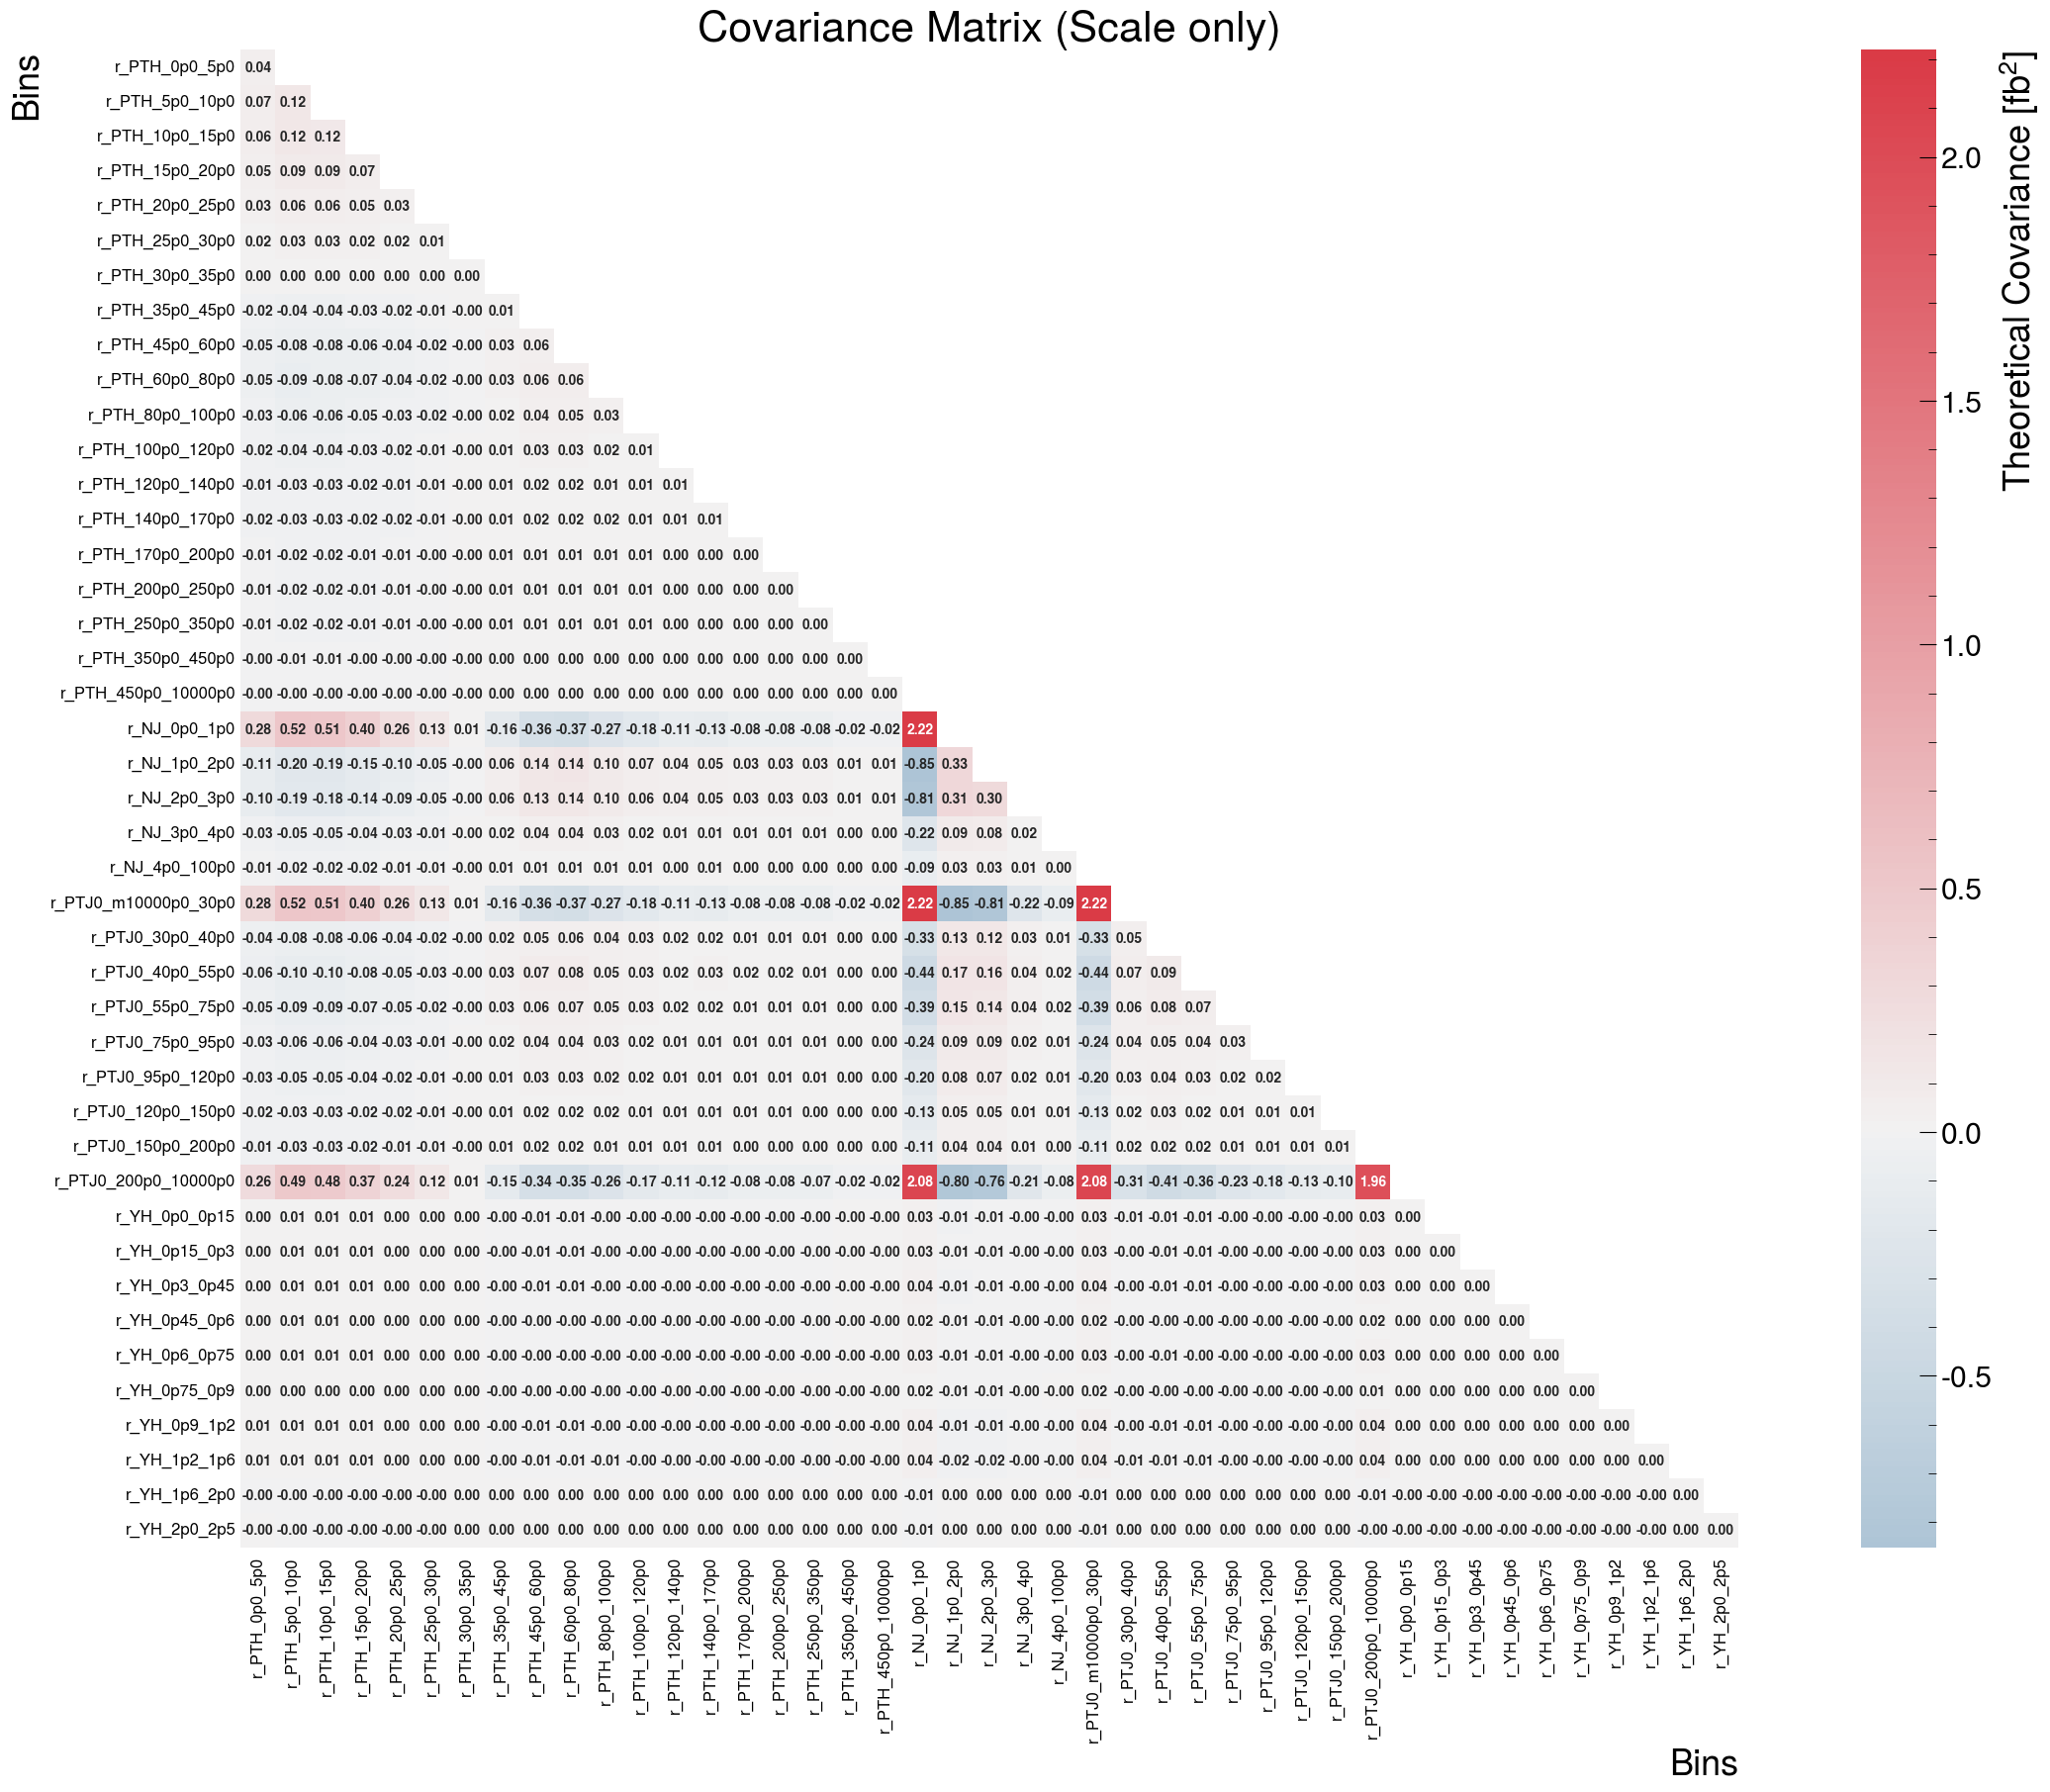

In [160]:
plot_cov(cov, title="Covariance Matrix (Scale only)")

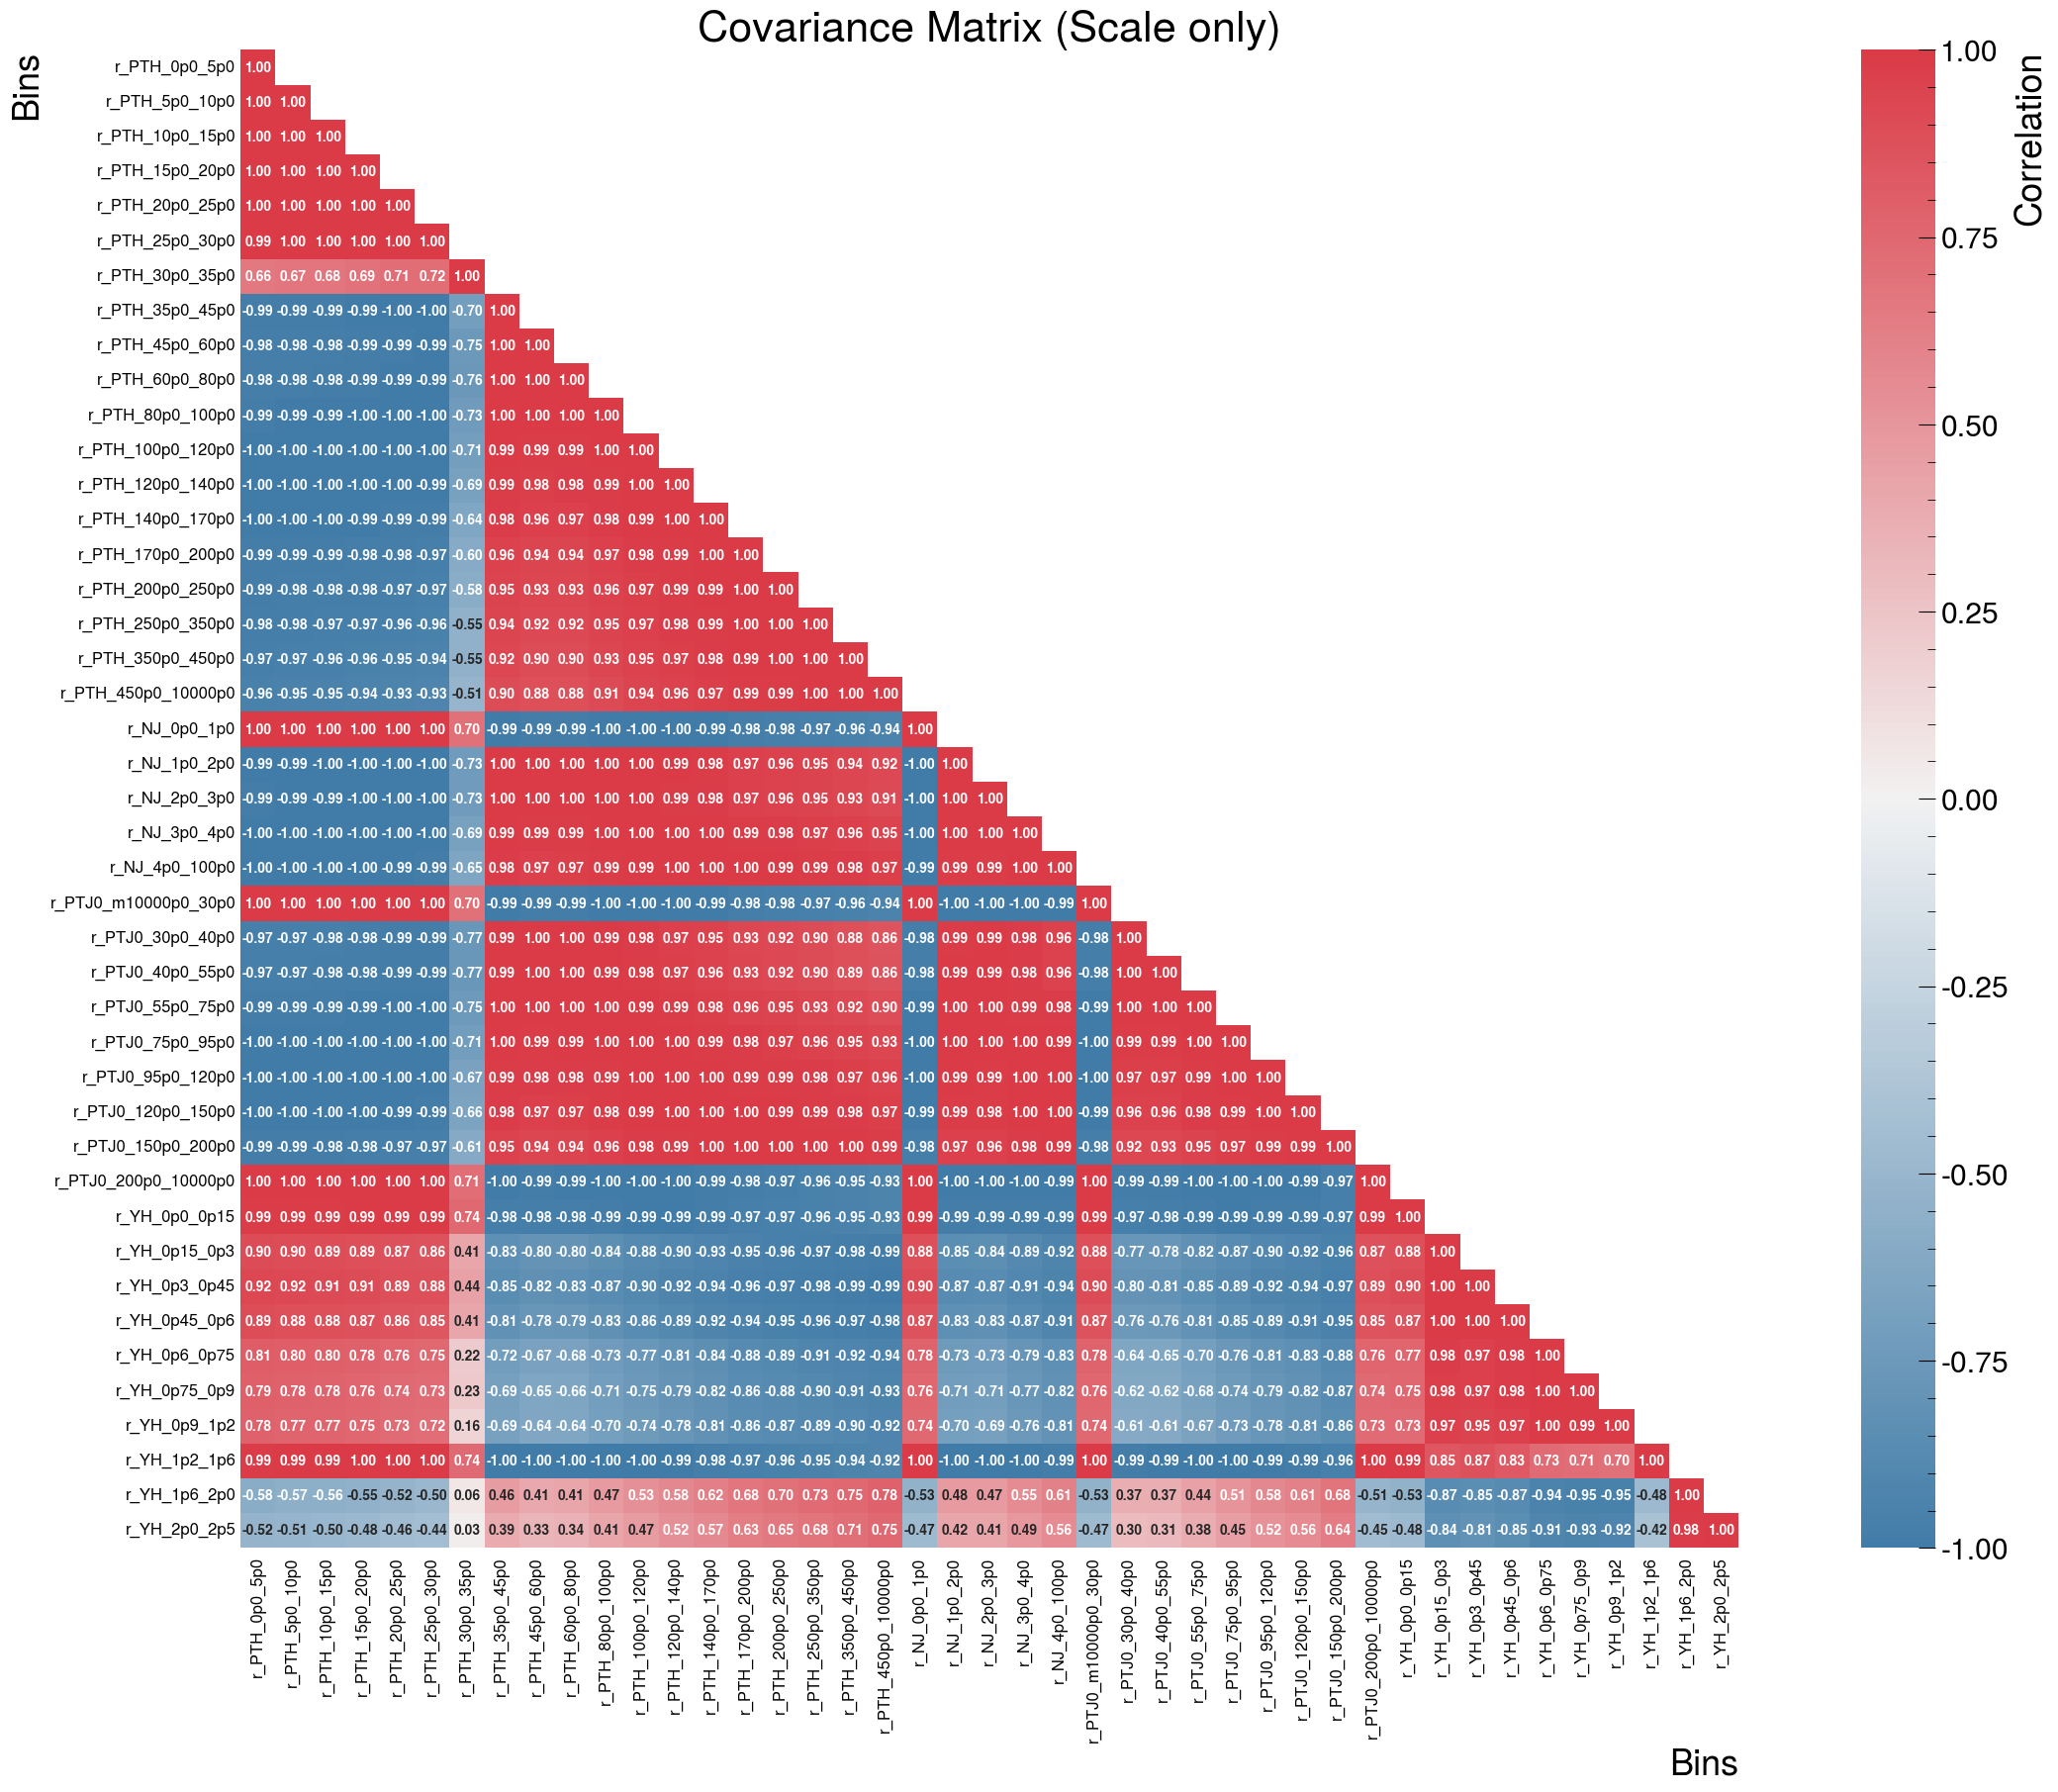

In [158]:
plot_corr(corr, title="Covariance Matrix (Scale only)")